<a href="https://colab.research.google.com/github/AidoruFusion/northstar-databases-analytics/blob/main/R_SQL_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: The SQL in R Analysis Workflow using `sqldf`

This notebook continues the NorthStar workflow after the Python cleaning and MongoDB preparation stages.

## The workflow

- The GitHub repository is accessed in Google Colab.
- The cleaned CSV files are loaded from `data/cleaned/csv/`.
- R and `sqldf` are used to run SQL queries on the cleaned data frames.
- Filtering, sorting, grouping, joins, CASE logic, and aggregation are applied.
- The outputs are interpreted in relation to NorthStar's operational problems.
- SQL result tables are saved for use in the final report.

This notebook supports the SQL in R requirement by applying SQL syntax directly to the cleaned NorthStar datasets.


## Accessing the GitHub repository

This section accesses the cleaned files from GitHub.

The notebook checks whether the repository already exists in Colab:
- if the repository exists, the latest version is pulled from GitHub;
- if the repository does not exist, it is cloned into Colab.

This keeps the workflow clear because the SQL analysis is based on the cleaned CSV files stored in the project repository.


In [ ]:
repo_url <- "https://github.com/AidoruFusion/northstar-databases-analytics.git"
repo_folder <- "/content/northstar-databases-analytics"

if (dir.exists(file.path(repo_folder, ".git"))) {
  print("Repository already exists. Pulling latest changes from GitHub...")
  system(paste("git -C", repo_folder, "pull origin main"), intern = FALSE)
} else {
  print("Cloning repository from GitHub...")
  system(paste("git clone", repo_url, repo_folder), intern = FALSE)
}

print("Repository ready.")
print(list.files(repo_folder))


[1] "Cloning repository from GitHub..."
[1] "Repository ready."
 [1] "_r_sql_.ipynb"             "app_events.csv"           
 [3] "app_events.json"           "complaints.csv"           
 [5] "complaints.json"           "customers.csv"            
 [7] "customers.json"            "data"                     
 [9] "data_dictionary.csv"       "data_dictionary.json"     
[11] "Database_Assignment.ipynb" "deliveries.csv"           
[13] "deliveries.json"           "drivers.csv"              
[15] "drivers.json"              "hubs.csv"                 
[17] "hubs.json"                 "incidents.csv"            
[19] "incidents.json"            "MongoDB_Notebook.ipynb"   
[21] "orders.csv"                "orders.json"              
[23] "README.md"                 "vehicles.csv"             
[25] "vehicles.json"            


## Locating the cleaned CSV files

This section points the notebook to the cleaned CSV folder inside the cloned GitHub repository.

Expected folder:

`/content/northstar-databases-analytics/data/cleaned/csv/`

If this folder does not show the cleaned files, the cleaned CSV files still need to be uploaded to GitHub under `data/cleaned/csv/`.


In [ ]:
cleaned_csv_folder <- file.path(repo_folder, "data", "cleaned", "csv")
analysis_output_folder <- file.path(repo_folder, "data", "analysis", "sql_r_outputs")

dir.create(analysis_output_folder, recursive = TRUE, showWarnings = FALSE)

print(paste("Cleaned CSV folder:", cleaned_csv_folder))
print("Files found in cleaned CSV folder:")
print(list.files(cleaned_csv_folder))

required_files <- c(
  "customers_cleaned.csv",
  "orders_cleaned.csv",
  "deliveries_cleaned.csv",
  "drivers_cleaned.csv",
  "vehicles_cleaned.csv",
  "hubs_cleaned.csv",
  "complaints_cleaned.csv",
  "incidents_cleaned.csv",
  "app_events_cleaned.csv"
)

missing_files <- required_files[!file.exists(file.path(cleaned_csv_folder, required_files))]

if (length(missing_files) > 0) {
  print("The following cleaned files are missing from the GitHub repo folder:")
  print(missing_files)
  stop("Upload the missing cleaned CSV files to GitHub under data/cleaned/csv/, then rerun Step 1 and Step 2.")
} else {
  print("All required cleaned CSV files are available from GitHub.")
}


[1] "Cleaned CSV folder: /content/northstar-databases-analytics/data/cleaned/csv"
[1] "Files found in cleaned CSV folder:"
 [1] "app_events_cleaned.csv"      "cleaning_summary.csv"       
 [3] "complaints_cleaned.csv"      "customers_cleaned.csv"      
 [5] "data_dictionary_cleaned.csv" "deliveries_cleaned.csv"     
 [7] "drivers_cleaned.csv"         "hubs_cleaned.csv"           
 [9] "incidents_cleaned.csv"       "orders_cleaned.csv"         
[11] "vehicles_cleaned.csv"       
[1] "All required cleaned CSV files are available from GitHub."


## Loading the cleaned CSV files

This section loads the cleaned CSV files from the GitHub repository folder into R data frames.

The data frames are then ready to be queried using SQL through the `sqldf` package.


In [ ]:
customers <- read.csv(file.path(cleaned_csv_folder, "customers_cleaned.csv"))
orders <- read.csv(file.path(cleaned_csv_folder, "orders_cleaned.csv"))
deliveries <- read.csv(file.path(cleaned_csv_folder, "deliveries_cleaned.csv"))
drivers <- read.csv(file.path(cleaned_csv_folder, "drivers_cleaned.csv"))
vehicles <- read.csv(file.path(cleaned_csv_folder, "vehicles_cleaned.csv"))
hubs <- read.csv(file.path(cleaned_csv_folder, "hubs_cleaned.csv"))
complaints <- read.csv(file.path(cleaned_csv_folder, "complaints_cleaned.csv"))
incidents <- read.csv(file.path(cleaned_csv_folder, "incidents_cleaned.csv"))
app_events <- read.csv(file.path(cleaned_csv_folder, "app_events_cleaned.csv"))

print("Cleaned datasets loaded successfully.")


[1] "Cleaned datasets loaded successfully."


## Checking the loaded data frames

This section confirms that the cleaned files loaded correctly by checking the number of rows and columns in each data frame.


In [ ]:
dataset_summary <- data.frame(
  dataset = c("customers", "orders", "deliveries", "drivers", "vehicles", "hubs", "complaints", "incidents", "app_events"),
  rows = c(nrow(customers), nrow(orders), nrow(deliveries), nrow(drivers), nrow(vehicles), nrow(hubs), nrow(complaints), nrow(incidents), nrow(app_events)),
  columns = c(ncol(customers), ncol(orders), ncol(deliveries), ncol(drivers), ncol(vehicles), ncol(hubs), ncol(complaints), ncol(incidents), ncol(app_events))
)

print(dataset_summary)
write.csv(dataset_summary, file.path(analysis_output_folder, "dataset_summary.csv"), row.names = FALSE)


     dataset rows columns
1  customers  650       9
2     orders 1250      11
3 deliveries  950      14
4    drivers  170       8
5   vehicles  120       8
6       hubs    8       5
7 complaints  320      10
8  incidents  280       7
9 app_events  640      10


## Preparing `sqldf` for SQL queries in R

The `sqldf` package allows SQL queries to be written directly against R data frames.

This supports the SQL in R requirement because the cleaned NorthStar datasets can be queried using SQL syntax.


In [ ]:
if (!require(sqldf)) {
  install.packages("sqldf", repos = "https://cloud.r-project.org")
  library(sqldf)
} else {
  library(sqldf)
}


Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



## Total orders by pickup zone

This query groups orders by pickup zone.

The output helps identify which city zones create the most demand and supports NorthStar's need to compare performance across locations.


In [ ]:
orders_by_zone <- sqldf("
SELECT pickup_zone,
       COUNT(*) AS total_orders,
       ROUND(AVG(order_value), 2) AS average_order_value
FROM orders
GROUP BY pickup_zone
ORDER BY total_orders DESC
")

print(orders_by_zone)
write.csv(orders_by_zone, file.path(analysis_output_folder, "orders_by_zone.csv"), row.names = FALSE)


  pickup_zone total_orders average_order_value
1     Central          238               88.45
2        East          207               91.77
3       South          181               90.58
4       North          174               91.03
5        West          155               88.27
6   Riverside          151               85.34
7     Airport          144              103.89


## Orders by service type

This query groups orders by service type.

The output shows whether demand is concentrated in passenger, parcel, medical, retail, or business services.


In [ ]:
orders_by_service <- sqldf("
SELECT service_type,
       COUNT(*) AS total_orders,
       ROUND(AVG(order_value), 2) AS average_order_value,
       ROUND(SUM(order_value), 2) AS total_order_value
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")

print(orders_by_service)
write.csv(orders_by_service, file.path(analysis_output_folder, "orders_by_service.csv"), row.names = FALSE)


  service_type total_orders average_order_value total_order_value
1    Passenger          341               96.07          32761.11
2       Parcel          308               87.62          26985.62
3       Retail          297               90.01          26734.06
4     Business          165               92.25          15220.43
5      Medical          139               87.14          12111.93


## Delivery performance by status

This query summarises delivery outcomes.

The output helps identify whether completed, failed, delayed, or exception-handled deliveries are affecting operational performance.


In [ ]:
delivery_status_summary <- sqldf("
SELECT delivery_status,
       COUNT(*) AS total_deliveries,
       ROUND(AVG(delivery_duration_hours), 2) AS average_duration_hours,
       ROUND(AVG(route_distance_km), 2) AS average_distance_km,
       ROUND(AVG(fuel_or_charge_cost), 2) AS average_cost
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC
")

print(delivery_status_summary)
write.csv(delivery_status_summary, file.path(analysis_output_folder, "delivery_status_summary.csv"), row.names = FALSE)


  delivery_status total_deliveries average_duration_hours average_distance_km
1          OnTime              616                   7.36               13.78
2         Delayed              202                  13.51               14.67
3          Failed              132                  17.78               13.37
  average_cost
1        12.68
2        13.14
3        13.15


## Connecting orders and deliveries

This query joins orders with deliveries using `order_id`.

The output connects customer bookings with delivery outcomes, supporting the case study's focus on linking fragmented operational records.


In [ ]:
orders_deliveries_join <- sqldf("
SELECT o.order_id,
       o.customer_id,
       o.service_type,
       o.pickup_zone,
       o.dropoff_zone,
       o.order_value,
       d.delivery_status,
       d.delivery_duration_hours,
       d.route_distance_km,
       d.manual_route_override_count,
       d.customer_rating_post_delivery
FROM orders o
LEFT JOIN deliveries d
ON o.order_id = d.order_id
LIMIT 20
")

print(orders_deliveries_join)
write.csv(orders_deliveries_join, file.path(analysis_output_folder, "orders_deliveries_join_sample.csv"), row.names = FALSE)


   order_id customer_id service_type pickup_zone dropoff_zone order_value
1    O00001       C0292    Passenger     Airport        South      126.65
2    O00002       C0459    Passenger       North      Airport      109.30
3    O00003       C0161    Passenger        West      Airport       33.50
4    O00004       C0520       Parcel   Riverside        North       10.04
5    O00005       C0558       Retail   Riverside        South      125.58
6    O00006       C0437       Retail     Central         East      151.44
7    O00007       C0001     Business     Central      Airport       76.12
8    O00008       C0157       Parcel   Riverside    Riverside       35.06
9    O00009       C0141       Retail       North         East       78.93
10   O00010       C0171       Retail       South        North       34.55
11   O00011       C0340       Parcel        West      Central       79.10
12   O00012       C0567     Business        East      Airport      135.67
13   O00013       C0234       Retail  

## Service performance by zone and service type

This query joins orders and deliveries, then groups results by pickup zone and service type.

The output helps identify combinations of location and service type where delivery times, costs, or customer ratings may be weaker.


In [ ]:
zone_service_performance <- sqldf("
SELECT o.pickup_zone,
       o.service_type,
       COUNT(*) AS total_records,
       ROUND(AVG(d.delivery_duration_hours), 2) AS average_duration_hours,
       ROUND(AVG(d.fuel_or_charge_cost), 2) AS average_cost,
       ROUND(AVG(d.customer_rating_post_delivery), 2) AS average_rating
FROM orders o
LEFT JOIN deliveries d
ON o.order_id = d.order_id
GROUP BY o.pickup_zone, o.service_type
ORDER BY average_duration_hours DESC
")

print(zone_service_performance)
write.csv(zone_service_performance, file.path(analysis_output_folder, "zone_service_performance.csv"), row.names = FALSE)


   pickup_zone service_type total_records average_duration_hours average_cost
1      Airport      Medical            17                  13.52        16.39
2        South      Medical            20                  13.11        12.23
3    Riverside      Medical            18                  12.82        12.98
4      Central       Parcel            55                  12.51        11.58
5        South       Parcel            44                  12.09        12.83
6    Riverside       Retail            36                  11.83        12.41
7      Central       Retail            65                  11.78        12.85
8         West    Passenger            42                  11.30        11.70
9      Central     Business            30                  11.22        11.12
10   Riverside    Passenger            39                  11.22        12.26
11        East    Passenger            55                  11.16        11.79
12        West      Medical            22                  10.93

## Complaints by type and severity

This query summarises complaints by complaint type and severity.

The output supports customer-experience analysis by identifying the most common and severe complaint categories.


In [ ]:
complaint_summary <- sqldf("
SELECT complaint_type,
       severity,
       COUNT(*) AS total_complaints,
       ROUND(AVG(resolution_days), 2) AS average_resolution_days,
       ROUND(AVG(compensation_amount), 2) AS average_compensation
FROM complaints
GROUP BY complaint_type, severity
ORDER BY total_complaints DESC
")

print(complaint_summary)
write.csv(complaint_summary, file.path(analysis_output_folder, "complaint_summary.csv"), row.names = FALSE)


      complaint_type severity total_complaints average_resolution_days
1              Delay   Medium               56                    5.96
2       MissedPickup   Medium               37                    6.16
3    DriverBehaviour   Medium               31                    5.42
4              Delay      Low               27                    6.48
5           AppIssue   Medium               25                    7.36
6              Delay     High               18                   12.44
7    DriverBehaviour     High               16                   13.75
8       MissedPickup     High               16                   11.56
9           AppIssue      Low               15                    6.07
10          AppIssue     High               13                   13.92
11 SupportExperience   Medium               12                    6.17
12      MissedPickup      Low               11                    6.91
13           Billing   Medium                9                    5.78
14    

## Connecting complaints with orders and deliveries

This query links complaints to customer orders and delivery records.

This is important because the case study states that customer complaints, failed services, missed journeys, and driver incidents need to be connected into one view.


In [ ]:
complaints_order_delivery <- sqldf("
SELECT c.complaint_id,
       c.customer_id,
       c.order_id,
       c.complaint_type,
       c.severity,
       c.status AS complaint_status,
       c.resolution_days,
       o.service_type,
       o.pickup_zone,
       d.delivery_status,
       d.delivery_duration_hours,
       d.customer_rating_post_delivery
FROM complaints c
LEFT JOIN orders o
ON c.order_id = o.order_id
LEFT JOIN deliveries d
ON c.order_id = d.order_id
LIMIT 30
")

print(complaints_order_delivery)
write.csv(complaints_order_delivery, file.path(analysis_output_folder, "complaints_order_delivery_sample.csv"), row.names = FALSE)


   complaint_id customer_id order_id    complaint_type severity
1        CP0001       C0464   O00814          AppIssue     High
2        CP0002       C0056   O00628      MissedPickup   Medium
3        CP0003       C0469   O00384             Delay     High
4        CP0004       C0631   O00406             Delay   Medium
5        CP0005       C0535   O00154             Delay   Medium
6        CP0006       C0096   O00147             Delay   Medium
7        CP0007       C0597   O00981      MissedPickup   Medium
8        CP0008       C0309   O00902          AppIssue     High
9        CP0009       C0340   O00011             Delay      Low
10       CP0010       C0486   O00417   DriverBehaviour   Medium
11       CP0011       C0618   O00437             Delay   Medium
12       CP0012       C0362   O00504          AppIssue     High
13       CP0013       C0157   O00008      MissedPickup   Medium
14       CP0014       C0545   O00980           Billing   Medium
15       CP0015       C0486   O00417    

## Driver performance and route overrides

This query joins drivers with deliveries and summarises route overrides and ratings.

The output supports analysis of whether driver experience, training, and performance are associated with operational disruption.


In [ ]:
driver_performance <- sqldf("
SELECT dr.driver_id,
       dr.base_zone,
       dr.employment_type,
       dr.years_experience,
       dr.training_score,
       dr.driver_rating,
       COUNT(d.delivery_id) AS total_deliveries,
       ROUND(AVG(d.manual_route_override_count), 2) AS average_route_overrides,
       ROUND(AVG(d.customer_rating_post_delivery), 2) AS average_customer_rating
FROM drivers dr
LEFT JOIN deliveries d
ON dr.driver_id = d.driver_id
GROUP BY dr.driver_id, dr.base_zone, dr.employment_type, dr.years_experience, dr.training_score, dr.driver_rating
ORDER BY average_route_overrides DESC
LIMIT 20
")

print(driver_performance)
write.csv(driver_performance, file.path(analysis_output_folder, "driver_performance.csv"), row.names = FALSE)


   driver_id base_zone employment_type years_experience training_score
1       D112      East        FullTime               14           79.1
2       D127   Central        FullTime               10           61.5
3       D021     South        FullTime                7           91.8
4       D051      West        FullTime                3           75.4
5       D060     South        FullTime                4           76.0
6       D062     South        FullTime               10           62.4
7       D069     North        PartTime                2           61.5
8       D079     South        PartTime                1             NA
9       D085     North        PartTime                9           84.5
10      D105 Riverside        Contract                2           82.0
11      D124     North        FullTime                4           70.6
12      D130      West        FullTime                8           71.2
13      D139     South        FullTime               10           71.4
14    

## Vehicle condition and delivery outcomes

This query joins vehicles with deliveries.

The output helps explore whether vehicle condition and maintenance status may be linked to delivery performance.


In [ ]:
vehicle_delivery_performance <- sqldf("
SELECT v.vehicle_id,
       v.vehicle_type,
       v.assigned_zone,
       v.maintenance_status,
       v.battery_health_pct,
       COUNT(d.delivery_id) AS total_deliveries,
       ROUND(AVG(d.delivery_duration_hours), 2) AS average_duration_hours,
       ROUND(AVG(d.fuel_or_charge_cost), 2) AS average_cost
FROM vehicles v
LEFT JOIN deliveries d
ON v.vehicle_id = d.vehicle_id
GROUP BY v.vehicle_id, v.vehicle_type, v.assigned_zone, v.maintenance_status, v.battery_health_pct
ORDER BY average_duration_hours DESC
LIMIT 20
")

print(vehicle_delivery_performance)
write.csv(vehicle_delivery_performance, file.path(analysis_output_folder, "vehicle_delivery_performance.csv"), row.names = FALSE)


   vehicle_id vehicle_type assigned_zone maintenance_status battery_health_pct
1        V037     CargoVan         South           InRepair               56.6
2        V075       Diesel          West           InRepair               85.5
3        V096     CargoVan          East           InRepair               85.1
4        V031           EV          East             Active               89.3
5        V117       Hybrid         South          Scheduled               65.5
6        V026     CargoVan     Riverside           InRepair               78.7
7        V108       Diesel       Airport           InRepair               54.6
8        V019       Diesel         South          Scheduled               70.4
9        V056           EV       Central             Active               78.4
10       V076       Diesel       Central           InRepair               65.8
11       V044           EV       Airport             Active               91.8
12       V046           EV         North            

## Incidents by severity and resolution status

This query summarises operational incidents.

The output supports analysis of whether unresolved or severe incidents may be contributing to service inefficiency.


In [ ]:
incident_summary <- sqldf("
SELECT incident_type,
       severity,
       resolution_status,
       COUNT(*) AS total_incidents,
       ROUND(AVG(resolved_hours), 2) AS average_resolved_hours
FROM incidents
GROUP BY incident_type, severity, resolution_status
ORDER BY total_incidents DESC
")

print(incident_summary)
write.csv(incident_summary, file.path(analysis_output_folder, "incident_summary.csv"), row.names = FALSE)


       incident_type severity resolution_status total_incidents
1     CustomerNoShow   Medium            Closed              10
2       ProofMissing      Low            Closed              10
3     RouteDeviation      Low            Closed              10
4       AppSyncError   Medium     PendingVendor               8
5       BatteryAlert   Medium            Closed               7
6   TemperatureIssue   Medium            Closed               7
7       BatteryAlert   Medium              Open               6
8     CustomerNoShow      Low              Open               6
9       ProofMissing   Medium            Closed               6
10    RouteDeviation     High              Open               6
11      VehicleFault   Medium            Closed               6
12      VehicleFault   Medium              Open               6
13      BatteryAlert      Low            Closed               5
14    CustomerNoShow     High            Closed               5
15    CustomerNoShow      Low     Pendin

## App event performance by zone

This query summarises app events by zone context.

The output helps analyse whether app performance issues may be concentrated in specific zones.


In [ ]:
app_event_zone_summary <- sqldf("
SELECT zone_context,
       event_type,
       COUNT(*) AS total_events,
       ROUND(AVG(api_latency_ms), 2) AS average_api_latency,
       ROUND(AVG(success_flag), 2) AS average_success_rate
FROM app_events
GROUP BY zone_context, event_type
ORDER BY average_api_latency DESC
")

print(app_event_zone_summary)
write.csv(app_event_zone_summary, file.path(analysis_output_folder, "app_event_zone_summary.csv"), row.names = FALSE)


   zone_context                  event_type total_events average_api_latency
1       Airport                 track_order           21              692.05
2       Airport delivery_instruction_update            9              677.11
3       Airport                 chat_opened           13              656.15
4       Central delivery_instruction_update            7              609.43
5          East              chat_escalated            4              586.00
6       Airport               payment_retry            9              579.22
7          West              chat_escalated            5              567.80
8       Central              cancel_attempt            4              564.25
9       Airport                 eta_refresh           10              562.60
10    Riverside                 chat_opened            8              544.75
11      Airport                search_route           17              541.53
12      Central              chat_escalated            8              533.88

## Delivery risk classification using SQL CASE logic

This query uses SQL `CASE` logic to classify deliveries as high, medium, or low risk.

The classification is based on delivery duration, route overrides, and customer rating.


In [ ]:
delivery_risk <- sqldf("
SELECT delivery_id,
       order_id,
       delivery_status,
       delivery_duration_hours,
       manual_route_override_count,
       customer_rating_post_delivery,
       CASE
         WHEN delivery_duration_hours > 6 OR manual_route_override_count >= 3 OR customer_rating_post_delivery < 3 THEN 'High Risk'
         WHEN delivery_duration_hours BETWEEN 3 AND 6 OR manual_route_override_count BETWEEN 1 AND 2 THEN 'Medium Risk'
         ELSE 'Low Risk'
       END AS delivery_risk_level
FROM deliveries
")

risk_summary <- sqldf("
SELECT delivery_risk_level,
       COUNT(*) AS total_deliveries
FROM delivery_risk
GROUP BY delivery_risk_level
ORDER BY total_deliveries DESC
")

print(risk_summary)
write.csv(delivery_risk, file.path(analysis_output_folder, "delivery_risk_records.csv"), row.names = FALSE)
write.csv(risk_summary, file.path(analysis_output_folder, "delivery_risk_summary.csv"), row.names = FALSE)


  delivery_risk_level total_deliveries
1           High Risk              551
2         Medium Risk              295
3            Low Risk              104


## Visualising SQL output

This chart visualises total orders by pickup zone.

The chart supports the SQL analysis by making zone demand easier to compare.


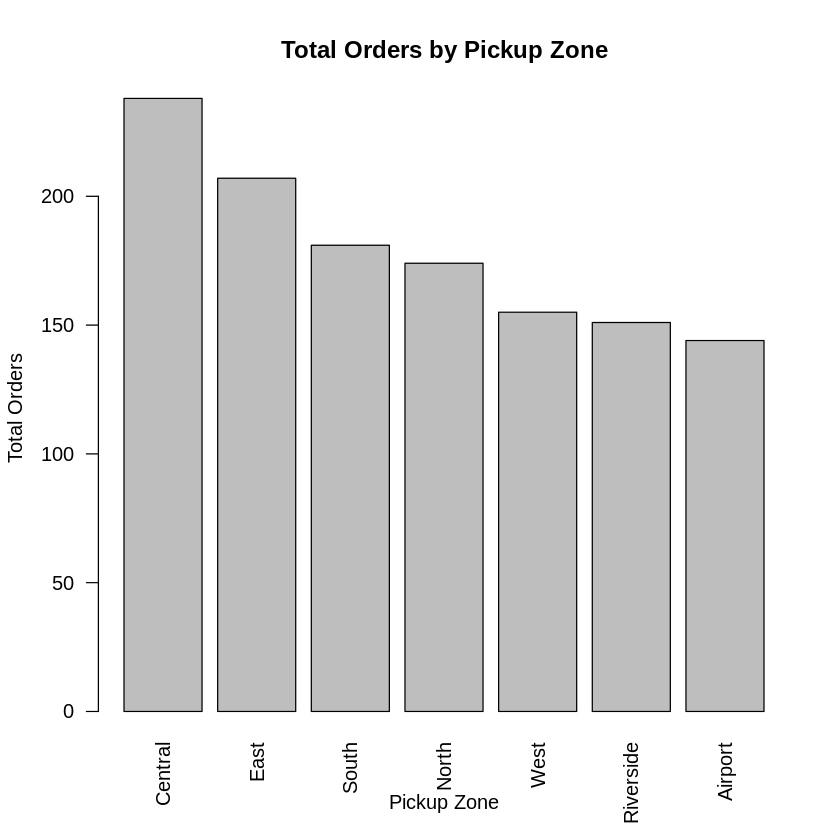

In [ ]:
barplot(
  orders_by_zone$total_orders,
  names.arg = orders_by_zone$pickup_zone,
  main = "Total Orders by Pickup Zone",
  xlab = "Pickup Zone",
  ylab = "Total Orders",
  las = 2
)


## Interpreting the SQL results

This section prints a short interpretation that can be adapted for the final report.

SQL in R was used to analyse the cleaned NorthStar datasets through filtering, grouping, aggregation, joins, and CASE logic.

The analysis supports the case study by connecting data that was previously fragmented across orders, deliveries, complaints, drivers, vehicles, incidents, hubs, and app events.

Key analytical areas included:
- demand by pickup zone and service type;
- delivery duration, cost, and customer rating;
- complaint severity and compensation;
- driver route overrides;
- vehicle condition and delivery outcomes;
- app latency and event success rates;
- risk classification for deliveries.

These outputs can support management decisions by showing where service performance issues appear across locations, service types, operational resources, and customer experience records.




## Checking the saved SQL outputs

This section checks that the SQL analysis outputs have been saved for use in the report.


In [ ]:
print(list.files(analysis_output_folder))


 [1] "app_event_zone_summary.csv"          
 [2] "complaint_summary.csv"               
 [3] "complaints_order_delivery_sample.csv"
 [4] "dataset_summary.csv"                 
 [5] "delivery_risk_records.csv"           
 [6] "delivery_risk_summary.csv"           
 [7] "delivery_status_summary.csv"         
 [8] "driver_performance.csv"              
 [9] "incident_summary.csv"                
[10] "orders_by_service.csv"               
[11] "orders_by_zone.csv"                  
[12] "orders_deliveries_join_sample.csv"   
[13] "vehicle_delivery_performance.csv"    
[14] "zone_service_performance.csv"        


## Final summary of the SQL in R workflow

This notebook completed the SQL in R stage of the NorthStar workflow.

The work completed includes:

- the cleaned CSV files were loaded from the GitHub project structure;
- `sqldf` was used to run SQL queries in R;
- SELECT, WHERE, GROUP BY, ORDER BY, JOIN, aggregation, and CASE logic were applied;
- orders, deliveries, complaints, drivers, vehicles, incidents, and app events were linked through SQL queries;
- SQL-based outputs were created for interpretation;
- result tables were saved for the final report.

The analysis supports the wider project by showing how cleaned structured data can be queried efficiently and interpreted in relation to NorthStar's fragmented operational environment.
